# BeeWatch AI · Analisi esplorativa del dataset USDA

**Task M2-T1** · Dataset: *Honey Production in the USA (1998-2012)*, Kaggle / USDA NASS.

## Obiettivo

Capire con che dati abbiamo a che fare **prima** di progettare il database (M2-T4) e il
modello di regressione (M4). In particolare rispondere a quattro domande:

1. Il dataset e' completo e coerente?
2. Quali colonne sono realmente indipendenti fra loro?
3. Che andamenti mostra nel tempo e nello spazio?
4. Quanto e' trasferibile a un apiario amatoriale italiano?

Le conclusioni motivate finiscono in `docs/markdown/M2-dati/dati.md`. Qui c'e' il procedimento.

## Come eseguirlo

Dalla radice del progetto, con l'ambiente virtuale attivo:

```
jupyter lab notebooks/01_eda.ipynb
```

Poi *Run All*. Il notebook non modifica nulla su disco: legge soltanto.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# La radice del progetto arriva da beewatch.config: un solo posto in cui e'
# definita, come per il resto dell'applicazione.
from beewatch.config import RADICE

PERCORSO_CSV = RADICE / "data" / "honeyproduction.csv"
LIBBRA_IN_KG = 0.45359237

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (9, 4.2), "axes.grid": True, "grid.alpha": 0.3})

print("CSV:", PERCORSO_CSV)
print("esiste:", PERCORSO_CSV.exists())

CSV: C:\Users\Imad\Desktop\beewatch-ai\data\honeyproduction.csv
esiste: True


## 1 · Caricamento e struttura

I tipi sono dichiarati esplicitamente invece di lasciarli dedurre a pandas: se un
giorno il file cambiasse formato, l'errore arriverebbe subito e sarebbe chiaro.

In [2]:
TIPI = {
    "state": "string",
    "numcol": "float64",
    "yieldpercol": "int64",
    "totalprod": "float64",
    "stocks": "float64",
    "priceperlb": "float64",
    "prodvalue": "float64",
    "year": "int64",
}

df = pd.read_csv(PERCORSO_CSV, dtype=TIPI)

print("righe, colonne:", df.shape)
df.head()

righe, colonne: (626, 8)


,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,"16,000.00",71,"1,136,000.00","159,000.00",0.72,"818,000.00",1998
1,AZ,"55,000.00",60,"3,300,000.00","1,485,000.00",0.64,"2,112,000.00",1998
2,AR,"53,000.00",65,"3,445,000.00","1,688,000.00",0.59,"2,033,000.00",1998
3,CA,"450,000.00",83,"37,350,000.00","12,326,000.00",0.62,"23,157,000.00",1998
4,CO,"27,000.00",72,"1,944,000.00","1,594,000.00",0.70,"1,361,000.00",1998


In [3]:
df.dtypes.to_frame("tipo")

,tipo
state,string
numcol,float64
yieldpercol,int64
totalprod,float64
stocks,float64
priceperlb,float64
prodvalue,float64
year,int64


### Valori mancanti e duplicati

Prima domanda da farsi su qualunque dataset. La risposta qui e' insolitamente pulita.

In [4]:
riepilogo = pd.DataFrame({
    "mancanti": df.isna().sum(),
    "% mancanti": (df.isna().mean() * 100).round(2),
    "valori distinti": df.nunique(),
})
print("duplicati sulla coppia (state, year):", df.duplicated(subset=["state", "year"]).sum())
riepilogo

duplicati sulla coppia (state, year): 0


,mancanti,% mancanti,valori distinti
state,0,0.00,44
numcol,0,0.00,148
yieldpercol,0,0.00,95
totalprod,0,0.00,517
stocks,0,0.00,500
priceperlb,0,0.00,210
prodvalue,0,0.00,589
year,0,0.00,15


## 2 · Copertura temporale e geografica

Il dataset copre 15 anni e 44 stati. Ma non tutti gli stati sono presenti in tutti
gli anni: e' un **pannello sbilanciato**, e questo ha conseguenze su come si
leggono gli andamenti aggregati.

In [5]:
print("anni:", df.year.min(), "-", df.year.max(), "| stati distinti:", df.state.nunique())

per_anno = df.groupby("year").agg(righe=("state", "size"), stati=("state", "nunique"))
per_stato = df.groupby("state").size().rename("anni_presenti")

print("\nstati con meno di 15 anni di dati:")
print(per_stato[per_stato < 15].sort_values().to_string())

per_anno.T

anni: 1998 - 2012 | stati distinti: 44

stati con meno di 15 anni di dati:
state
SC     3
MD     6
OK     6
NV    11


year,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012
righe,43,43,43,44,44,44,41,41,41,41,41,40,40,40,40
stati,43,43,43,44,44,44,41,41,41,41,41,40,40,40,40


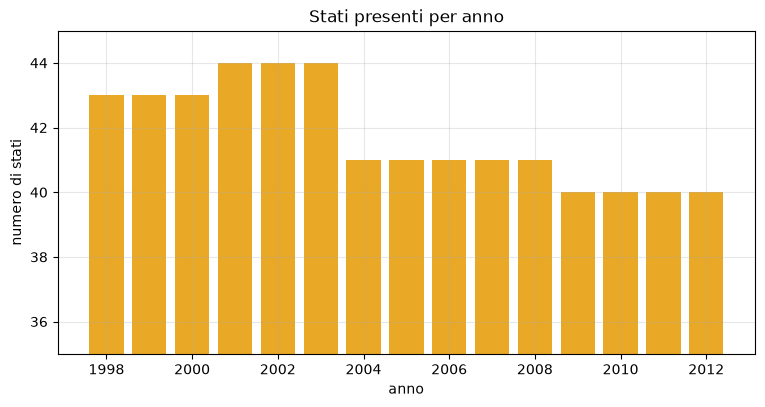

In [6]:
fig, ax = plt.subplots()
ax.bar(per_anno.index, per_anno.stati, color="#E9A825")
ax.set(title="Stati presenti per anno", xlabel="anno", ylabel="numero di stati")
ax.set_ylim(35, 45)
plt.show()

## 3 · Coerenza interna: le colonne sono davvero otto?

Prima di scegliere un target per la regressione bisogna sapere quali colonne sono
**derivate** da altre. Una colonna calcolata usata come predittore non e' un
predittore: e' la risposta scritta in fondo alla pagina.

In [7]:
calcolata = df.numcol * df.yieldpercol
identiche = np.isclose(calcolata, df.totalprod).sum()
print(f"totalprod == numcol x yieldpercol  ->  {identiche} righe su {len(df)}")
print("scarto massimo:", (calcolata - df.totalprod).abs().max())

totalprod == numcol x yieldpercol  ->  626 righe su 626
scarto massimo: 0.0


In [8]:
valore_calcolato = df.totalprod * df.priceperlb
scarto = (valore_calcolato - df.prodvalue).abs()
print("prodvalue vs totalprod x priceperlb")
print(f"  scarto assoluto massimo : {scarto.max():,.0f} dollari")
print(f"  scarto relativo massimo : {(scarto / df.prodvalue).max():.4%}")
print("  -> compatibile con un arrotondamento al migliaio di dollari")

prodvalue vs totalprod x priceperlb
  scarto assoluto massimo : 500 dollari
  scarto relativo massimo : 0.2235%
  -> compatibile con un arrotondamento al migliaio di dollari


**Conseguenza.** Delle otto colonne, solo cinque portano informazione indipendente:
`state`, `year`, `numcol`, `yieldpercol`, `priceperlb`, piu' `stocks`.
`totalprod` e `prodvalue` sono prodotti esatti delle altre.

Questo esclude `totalprod` come target di regressione: un modello che riceve
`numcol` e `yieldpercol` otterrebbe R² = 1 imparando una moltiplicazione.
Il target ragionevole e' **`yieldpercol`**, la resa per colonia (vedi M2-T3).

## 4 · Distribuzioni

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
numcol,626.00,"60,284.35","91,077.09","2,000.00","9,000.00","26,000.00","63,750.00","510,000.00"
yieldpercol,626.00,62.01,19.46,19.00,48.00,60.00,74.00,136.00
totalprod,626.00,"4,169,086.26","6,883,846.75","84,000.00","475,000.00","1,533,000.00","4,175,250.00","46,410,000.00"
stocks,626.00,"1,318,859.42","2,272,963.67","8,000.00","143,000.00","439,500.00","1,489,500.00","13,800,000.00"
priceperlb,626.00,1.41,0.64,0.49,0.93,1.36,1.68,4.15
prodvalue,626.00,"4,715,741.21","7,976,109.77","162,000.00","759,250.00","1,841,500.00","4,703,250.00","69,615,000.00"
year,626.00,"2,004.86",4.32,"1,998.00","2,001.00","2,005.00","2,009.00","2,012.00"


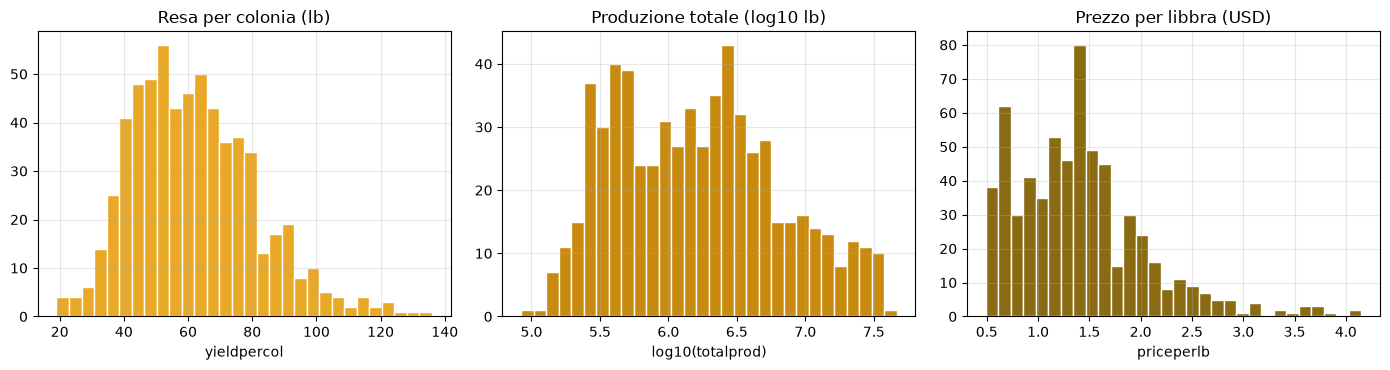

In [10]:
fig, assi = plt.subplots(1, 3, figsize=(14, 3.8))

assi[0].hist(df.yieldpercol, bins=30, color="#E9A825", edgecolor="white")
assi[0].set(title="Resa per colonia (lb)", xlabel="yieldpercol")

assi[1].hist(np.log10(df.totalprod), bins=30, color="#C98A10", edgecolor="white")
assi[1].set(title="Produzione totale (log10 lb)", xlabel="log10(totalprod)")

assi[2].hist(df.priceperlb, bins=30, color="#8A6A12", edgecolor="white")
assi[2].set(title="Prezzo per libbra (USD)", xlabel="priceperlb")

plt.tight_layout()
plt.show()

`yieldpercol` e' l'unica variabile con una distribuzione ragionevolmente simmetrica.
`totalprod`, `numcol`, `stocks` e `prodvalue` sono fortemente asimmetriche a destra:
dipendono dalla dimensione dello stato, non da un fenomeno biologico.

## 5 · Outlier

La regola IQR segnala molte righe. La domanda giusta non e' *quante* sono, ma *chi*
sono: un valore estremo ricorrente non e' un errore, e' una caratteristica.

In [11]:
def fuori_intervallo(serie: pd.Series, fattore: float = 1.5) -> pd.Series:
    """Maschera booleana dei valori fuori dall'intervallo IQR."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - fattore * iqr) | (serie > q3 + fattore * iqr)


colonne = ["numcol", "yieldpercol", "totalprod", "stocks", "priceperlb", "prodvalue"]
conteggio = {c: int(fuori_intervallo(df[c]).sum()) for c in colonne}
pd.DataFrame({"righe fuori IQR": conteggio,
              "% del totale": {c: round(v / len(df) * 100, 1) for c, v in conteggio.items()}})

,righe fuori IQR,% del totale
numcol,63,10.10
yieldpercol,12,1.90
totalprod,75,12.00
stocks,54,8.60
priceperlb,22,3.50
prodvalue,76,12.10


In [12]:
sospetti = df[fuori_intervallo(df.totalprod)]
print("chi produce gli outlier di totalprod (numero di anni in cui compare):")
print(sospetti.state.value_counts().to_string())

chi produce gli outlier di totalprod (numero di anni in cui compare):
state
CA    15
FL    15
ND    15
SD    15
MT     8
MN     7


Quattro stati compaiono in **tutti e 15** gli anni. Non sono errori di misura: sono
i grandi produttori. Rimuoverli significherebbe cancellare piu' della meta' della
produzione nazionale.

## 6 · Andamenti nel tempo

Per confrontare gli anni fra loro bisogna usare solo i **40 stati presenti in tutti
e 15 gli anni**: altrimenti il calo del totale rifletterebbe in parte l'uscita di
stati dal campione, non un fenomeno reale.

In [13]:
stati_completi = per_stato[per_stato == 15].index
panel = df[df.state.isin(stati_completi)]

serie = panel.groupby("year").agg(
    colonie=("numcol", "sum"),
    produzione=("totalprod", "sum"),
    resa_media=("yieldpercol", "mean"),
    prezzo_medio=("priceperlb", "mean"),
)

variazione = (serie.iloc[-1] / serie.iloc[0] - 1) * 100
print("variazione 1998 -> 2012, pannello bilanciato (40 stati):")
print(variazione.round(1).to_string())
serie

variazione 1998 -> 2012, pannello bilanciato (40 stati):
colonie         -3.50
produzione     -35.50
resa_media     -23.00
prezzo_medio   197.60


,colonie,produzione,resa_media,prezzo_medio
year,,,,
1998,"2,600,000.00","218,547,000.00",71.67,0.80
1999,"2,616,000.00","201,436,000.00",66.97,0.75
2000,"2,581,000.00","218,687,000.00",69.75,0.75
2001,"2,518,000.00","184,646,000.00",66.42,0.85
2002,"2,545,000.00","169,940,000.00",67.10,1.32
2003,"2,576,000.00","180,483,000.00",63.23,1.45
2004,"2,525,000.00","181,959,000.00",65.05,1.27
2005,"2,382,000.00","173,417,000.00",64.72,1.15
2006,"2,369,000.00","153,905,000.00",62.48,1.25


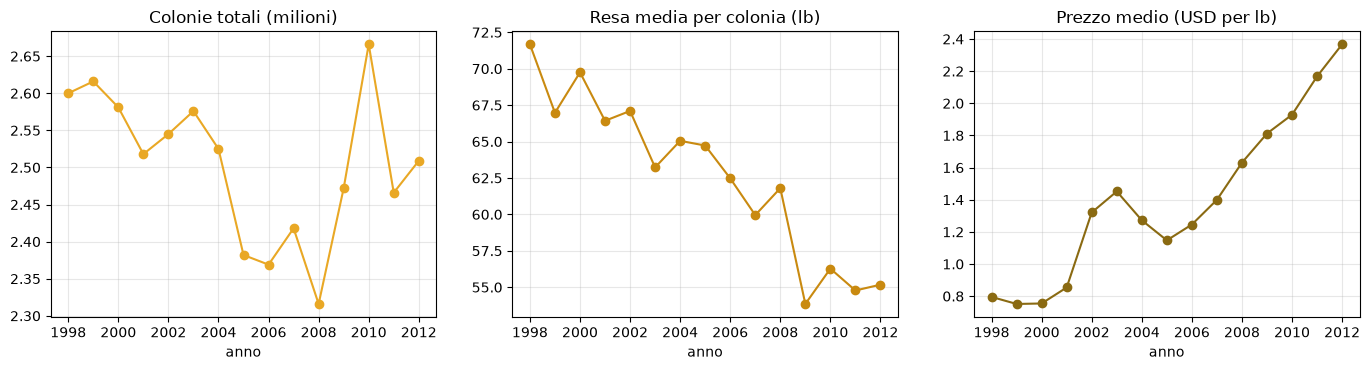

In [14]:
fig, assi = plt.subplots(1, 3, figsize=(14, 3.8))

assi[0].plot(serie.index, serie.colonie / 1e6, marker="o", color="#E9A825")
assi[0].set(title="Colonie totali (milioni)", xlabel="anno")

assi[1].plot(serie.index, serie.resa_media, marker="o", color="#C98A10")
assi[1].set(title="Resa media per colonia (lb)", xlabel="anno")

assi[2].plot(serie.index, serie.prezzo_medio, marker="o", color="#8A6A12")
assi[2].set(title="Prezzo medio (USD per lb)", xlabel="anno")

plt.tight_layout()
plt.show()

Il numero di colonie e' quasi stabile, la resa per colonia crolla, il prezzo esplode.
Il calo della produzione **non** e' spiegato da meno alveari: e' spiegato da alveari
meno produttivi. E' il periodo del *Colony Collapse Disorder*.

## 7 · Geografia

In [15]:
per_stato_prod = df.groupby("state").agg(
    produzione=("totalprod", "sum"),
    resa_media=("yieldpercol", "mean"),
    anni=("year", "size"),
).sort_values("produzione", ascending=False)
per_stato_prod["quota"] = per_stato_prod.produzione / per_stato_prod.produzione.sum()

print(f"quota dei primi 5 stati : {per_stato_prod.quota.head(5).sum():.1%}")
print(f"quota degli ultimi 10   : {per_stato_prod.quota.tail(10).sum():.1%}")
per_stato_prod.head(8)

quota dei primi 5 stati : 57.2%
quota degli ultimi 10   : 1.4%


,produzione,resa_media,anni,quota
state,,,,
ND,"475,085,000.00",88.07,15,0.18
CA,"347,535,000.00",55.80,15,0.13
SD,"266,141,000.00",75.80,15,0.10
FL,"247,048,000.00",83.07,15,0.09
MT,"156,562,000.00",77.33,15,0.06
MN,"144,360,000.00",74.27,15,0.06
TX,"104,904,000.00",70.53,15,0.04
WI,"81,833,000.00",79.40,15,0.03


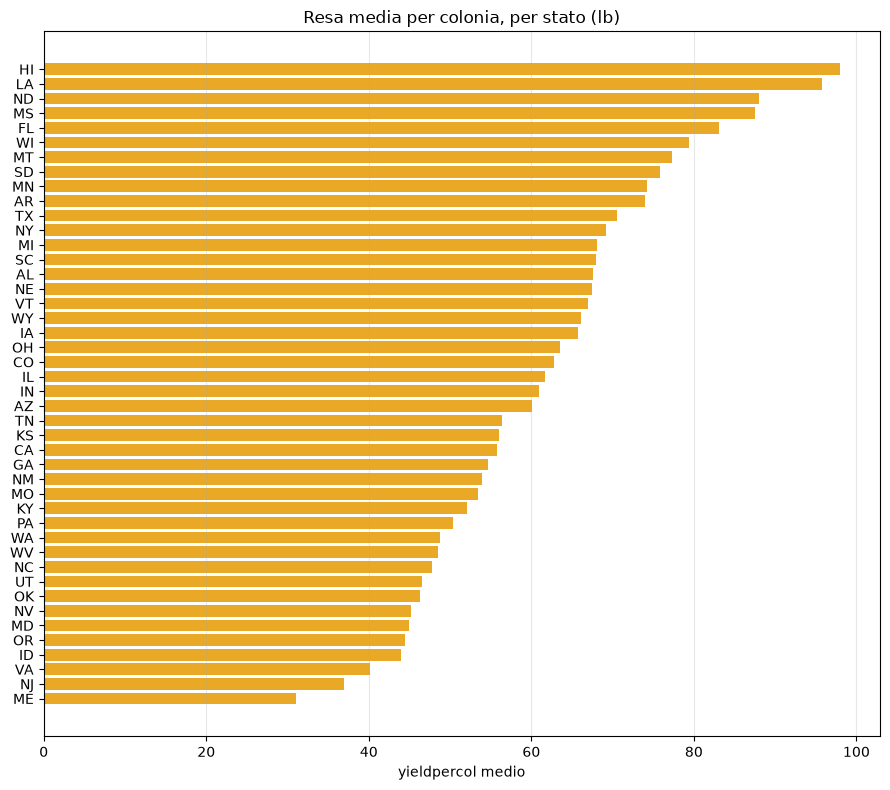

In [16]:
resa = df.groupby("state").yieldpercol.mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(resa.index, resa.values, color="#E9A825")
ax.set(title="Resa media per colonia, per stato (lb)", xlabel="yieldpercol medio")
ax.grid(axis="y", alpha=0)
plt.tight_layout()
plt.show()

## 8 · Correlazioni

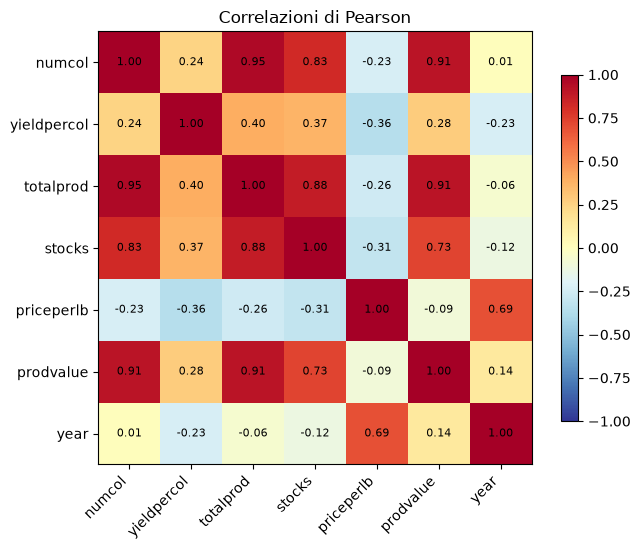

In [17]:
numeriche = ["numcol", "yieldpercol", "totalprod", "stocks", "priceperlb", "prodvalue", "year"]
matrice = df[numeriche].corr()

fig, ax = plt.subplots(figsize=(7, 5.6))
immagine = ax.imshow(matrice, cmap="RdYlBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeriche)), numeriche, rotation=45, ha="right")
ax.set_yticks(range(len(numeriche)), numeriche)
for i in range(len(numeriche)):
    for j in range(len(numeriche)):
        ax.text(j, i, f"{matrice.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(immagine, shrink=0.8)
ax.grid(False)
ax.set_title("Correlazioni di Pearson")
plt.tight_layout()
plt.show()

Da leggere con prudenza: le correlazioni alte fra `numcol`, `totalprod` e `prodvalue`
sono l'identita' algebrica vista al punto 3, non una relazione empirica.
L'unica correlazione interessante e' `priceperlb` con `year`.

## 9 · Anomalie puntuali

In [18]:
scorte_maggiori = df[df.stocks > df.totalprod]
print("righe con scorte maggiori della produzione dell'anno:", len(scorte_maggiori))
scorte_maggiori[["state", "year", "totalprod", "stocks"]]

righe con scorte maggiori della produzione dell'anno: 1


,state,year,totalprod,stocks
364,NE,2006,"3,431,000.00","3,843,000.00"


Una riga su 626. Non e' necessariamente un errore: le scorte a fine anno includono
l'invenduto degli anni precedenti, quindi possono superare la produzione annuale.
Va segnalata, non corretta d'ufficio.

In [19]:
COLONNE_RESA = ["state", "year", "yieldpercol", "numcol"]

print("resa piu' alta:")
print(df.nlargest(4, "yieldpercol")[COLONNE_RESA].to_string(index=False))
print("\nresa piu' bassa:")
print(df.nsmallest(4, "yieldpercol")[COLONNE_RESA].to_string(index=False))

resa piu' alta:
state  year  yieldpercol     numcol
   HI  2002          136   7,000.00
   HI  2005          131   9,000.00
   ND  1998          128 230,000.00
   LA  2002          124  35,000.00

resa piu' bassa:
state  year  yieldpercol    numcol
   NJ  2003           19 10,000.00
   ME  2001           20 11,000.00
   ME  2000           21 11,000.00
   ME  1999           22 14,000.00


Gli estremi hanno una spiegazione geografica: alle Hawaii la fioritura e' continua
tutto l'anno, nel Maine la stagione utile e' di poche settimane. Sono dati veri.

## 10 · Trasferibilita' al caso d'uso

Il prodotto e' pensato per un apicoltore amatoriale italiano. Il dataset descrive
produzione **commerciale statunitense aggregata per stato**. La conversione in
unita' comprensibili serve a misurare la distanza fra i due mondi.

In [20]:
resa = df.yieldpercol

for etichetta, valore in [
    ("media", resa.mean()),
    ("mediana", resa.median()),
    ("minimo", resa.min()),
    ("massimo", resa.max()),
]:
    print(f"{etichetta:9s}: {valore:6.1f} lb = {valore * LIBBRA_IN_KG:5.1f} kg per colonia")

media    :   62.0 lb =  28.1 kg per colonia
mediana  :   60.0 lb =  27.2 kg per colonia
minimo   :   19.0 lb =   8.6 kg per colonia
massimo  :  136.0 lb =  61.7 kg per colonia


## Conclusioni

Le osservazioni motivate, le anomalie e le conseguenze progettuali sono raccolte in
**`docs/markdown/M2-dati/dati.md`**. Le regole di pulizia e il dizionario colonna per colonna sono
la task successiva, **M2-T2**.